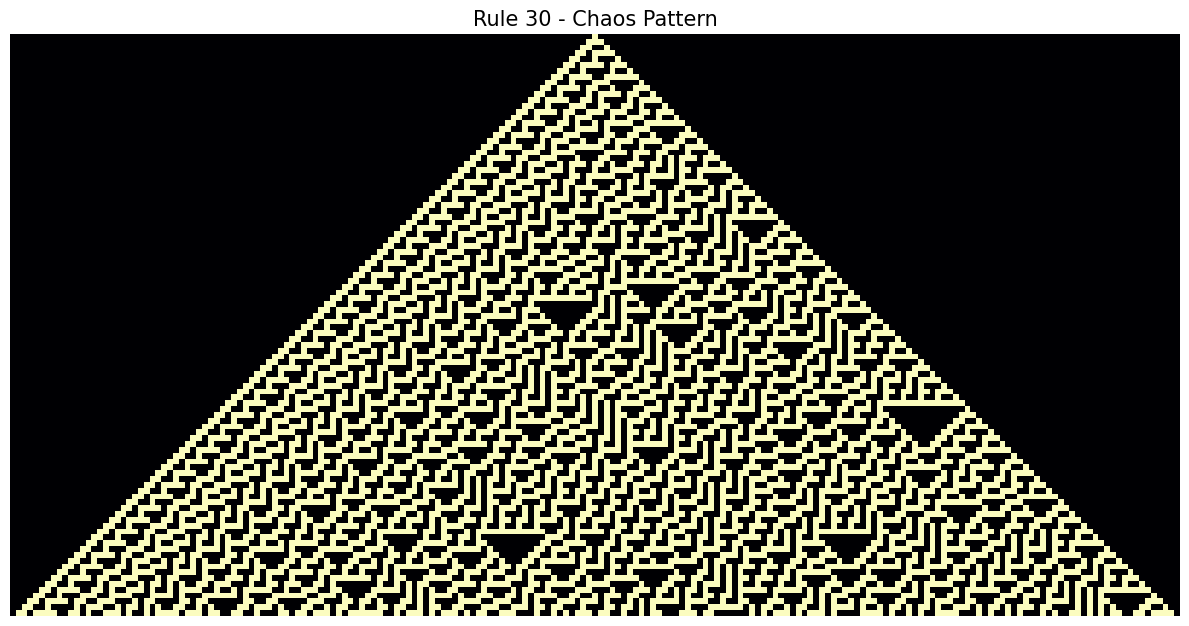

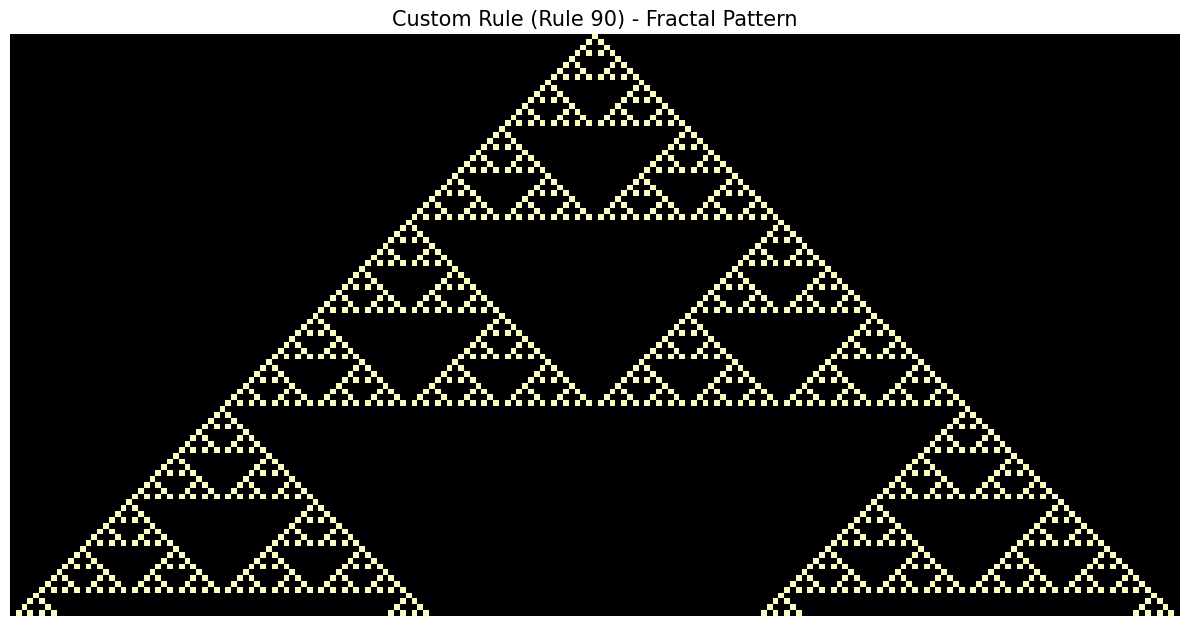

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# provide with 4 parameters realizing specified rules, grid size, iteration and initial cells)
def generate_ca(rule_input, width=100, steps=50, init_row=None):

    if isinstance(rule_input, int): # a built-in function 'isinstance' to judge if instance int type
        # if input int, transfer decimal input to binary, and compulsory as a list with 8 bits
        rule_bin = [int(x) for x in np.binary_repr(rule_input, width=8)]
    else:
        # given a standard mapping pattern starting with '111' corresponding to the digit of 2**(8-1) end with '000' which is 2**0
        # if input not int, default as strings and judge corresponding to which digit those combination given in input that lead to live
        patterns = ['111', '110', '101', '100', '011', '010', '001', '000']
        rule_bin = [1 if p in rule_input else 0 for p in patterns]

    # above we got a list with 8 elements consist of 1 or 0, now we create a dict: key of dict is the index of the list 'rule_bin' which means the combination to be judged, and the value of dict is the value of the list 'rule_bin' which means the judgement survive(1) or die(0).
    # for example if the value of index = 0 in rule_bin is 0, index = 0 means combination '111' and value = 0 means to be judged as death
    # enumerate gives index to each element in rule_bin and return 8 tuple starting with (0,v)
    # 7-i inverses the indices' order as key's order because smaller key refers to larger combination (7 refers to '111'), v as value. loop i, v in tuples
    rule_map = {7-i: v for i, v in enumerate(rule_bin)}

    # define an all-zero array, with storage type as int (only 0 or 1)
    history = np.zeros((steps, width), dtype=int)
    # if the parameter of first row(initial) is given, us the given one
    if init_row is not None:
        history[0] = init_row
    # if not given, set only the midpoint as 0 in first row
    else:
        history[0, width // 2] = 1  # 默认中间一个点为 1

    # loop for steps given, starting from 0
    for t in range(steps - 1):
        # for each iteration(step), obtain a value for cells(left, self and right) by row indices(t) and column indices(width) and %obtains mod to keep boundaries continuous
        for i in range(width):
            # 获取左、中、右邻居，使用取模运算实现循环边界 (Periodic Boundary)
            left  = history[t, (i - 1) % width]
            mid   = history[t, i]
            right = history[t, (i + 1) % width]

            # to avoid internal storage type transferring(int to string, string to int), using shift to move bits of left and self. concat them as combination, and transfer to decimal for judging--<<2 equals to *4; <<1 equals to *2
            idx = (left << 2) | (mid << 1) | right
            # locating each of cells to be updating next iteration, and give idx as key to the dict, obtain the value(1 or 0--survive or die)
            history[t + 1, i] = rule_map[idx]

    return history

def plot_ca(data, title="Cellular Automata"):
    plt.figure(figsize=(12, 8))
    # 使用 'binary' 或者是 'magma' 等色标，插值选 'nearest' 保证像素感
    plt.imshow(data, cmap='magma', interpolation='nearest')
    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- 使用示例 ---

# 示例 A：输入 Rule 30 编号
data_30 = generate_ca(rule_input=30, width=201, steps=100)
plot_ca(data_30, "Rule 30 - Chaos Pattern")

# 示例 B：输入 8 个由 01 构成的字符串 (模拟 Rule 90: 只有左右不同时为1)
# Rule 90 对应的 1 模式是：110, 100, 011, 001
rule_90_patterns = ['110', '100', '011', '001']
data_custom = generate_ca(rule_input=rule_90_patterns, width=201, steps=100)
plot_ca(data_custom, "Custom Rule (Rule 90) - Fractal Pattern")

In [17]:
test_input1 = ['110', '011', '101', '000']
patterns1 = ['111', '110', '101', '100', '011', '010', '001', '000']
rule_bin1 = [1 if p in test_input1 else 0 for p in patterns1]
print(f"rule_bin1: {rule_bin1}")

test_enumerate = enumerate(rule_bin1)
print(f"enumerate: {test_enumerate}")
for i, v in test_enumerate:
    print(f"indices: {i}, with the value of: {v}")

test_map1 = {7-i: v for i, v in enumerate(rule_bin1)} # test_map1 = {7-i: v for i, v in test_enumerate}❌️，enumerate--iterator for only one time using
test_map2 = {i: v for i, v in enumerate(rule_bin1)}
print(f"test_map1: {test_map1}")
print(f"test_map2: {test_map2}")

test_input2 = 46
test_binary = np.binary_repr(test_input2, width=8)
print(f"test_binary: {test_binary}")

a=1
b=0
c=1
test_shift = (a << 2) | (b << 1) | c
print("test_shift = ", test_shift)

rule_bin1: [0, 1, 1, 0, 1, 0, 0, 1]
enumerate: <enumerate object at 0x000002967A7E8C80>
indices: 0, with the value of: 0
indices: 1, with the value of: 1
indices: 2, with the value of: 1
indices: 3, with the value of: 0
indices: 4, with the value of: 1
indices: 5, with the value of: 0
indices: 6, with the value of: 0
indices: 7, with the value of: 1
test_map1: {7: 0, 6: 1, 5: 1, 4: 0, 3: 1, 2: 0, 1: 0, 0: 1}
test_map2: {0: 0, 1: 1, 2: 1, 3: 0, 4: 1, 5: 0, 6: 0, 7: 1}
test_binary: 00101110
test_shift =  5
